# Simulating and generation of segmented XCT data of cotton fibres

### Imports

In [ ]:
import os
import sys
from pathlib import Path
import ipynbname

import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread

from gvxrPython3 import gvxr

from gvxrPython3.JSON2gVXRDataReader import *

import tifffile as tiff

#3D viewing and interacting
from ipywidgets import interact
import pyvista as pv

xsim_root = ipynbname.path().parent.parent.parent
print(xsim_root)

class_root = xsim_root / "Classes"
print(class_root)

sys.path.append(str(xsim_root))

#own class imports
from Classes.Nanotom_class.NanotomXCT import NanotomXCT
from Classes.Comparisor_class.xct_comparisor import *
from Classes.Mesh_Handler_class.Mesh_Handler import Mesh_Handler
from Classes.Segmentation_class.Segmentation import Segmentation

c:\Users\SEALMQVISTE\.vscode\Git-MastersThesis\x-ray_sim
c:\Users\SEALMQVISTE\.vscode\Git-MastersThesis\x-ray_sim\Classes


In [2]:
output_path = xsim_root / "Results/Cotton fibre/"
data_root = xsim_root / "Data/"
meshes_root = xsim_root / "Data/Cotton fibre/Meshes/"

print(output_path)
print(meshes_root)
print(data_root)

c:\Users\SEALMQVISTE\.vscode\Git-MastersThesis\x-ray_sim\Results\Cotton fibre
c:\Users\SEALMQVISTE\.vscode\Git-MastersThesis\x-ray_sim\Data\Cotton fibre\Meshes
c:\Users\SEALMQVISTE\.vscode\Git-MastersThesis\x-ray_sim\Data


In [3]:
mh = Mesh_Handler()

### Importing meshes

In [4]:
fibres_folder = Path(str(meshes_root) + "/cotton_fibres")
        
files = fibres_folder.glob(f"{"fibre"}_*.stl")

meshes = [str(f) for f in files]
print(len(meshes))

10


### Rescale meshes

In [5]:
meshes_rescaled = mh.rescale_meshes(fibres_folder, 2, 2/1000)

### Center meshes

In [6]:
meshes_scaled_moved = mh.center_meshes(meshes_rescaled)

In [7]:
folder = Path(meshes_scaled_moved)
files = folder.glob(f"{"fibre"}_*.stl")

meshes = [str(f) for f in files]
print(len(meshes))

10


### Setting up parameters based on the experimental parameters

In [8]:
SDD=600
SSD=4.5

mag = SDD/SSD

scaling = 1
current = 0.3 #mA
exp_time = 0.375013 #s
volt = 60 #kV

detector_x = 996
detector_y = 1200

num_of_proj = int(np.round(detector_x * np.pi/2))


In [9]:
nanotom = NanotomXCT(scaling, output_path=output_path)

nanotom.set_distances(SSD, SDD)
nanotom.setup_detector(detector_x, detector_y)
nanotom.setup_source(volt, current, exp_time, poly=True, noise=True)

nanotom.print_geometries()

s = sp.Spek(kvp= 60 , th= 12 , mas= 0.11250389999999999 , z= 60.0
264225490.333315  photons / cm^2
26422.54862853622  photons / pixel
FoV = (0.747, 0.9) mm
Voxel size = 0.75 um
Number of projections needed: 1565


### Modelled mixture and mass fraction of cotton fibre

In [10]:
cotton_mix = ["C", "H", "O"]
cotton_mf = [0.444, 0.062, 0.494]

In [11]:
mix = np.array([cotton_mix, cotton_mf], dtype=object)

In [12]:
i = 1
for mesh in meshes:
    nanotom.addMesh(f"fibre_{i}", mesh, density=0.5, mixture=mix[0], mass_fraction=mix[1])
    i += 1

### Simulatig a projection

(-0.5, 995.5, 1199.5, -0.5)

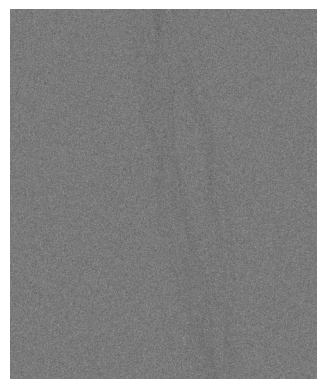

In [13]:
im = nanotom.compute2D("yarn")
plt.imshow(im, cmap="gray")
plt.axis("off")

### Acquisition and reconstruction

In [ ]:
FFC = 0 #Flat-Field Correct, Enables ring artifacts in the simulation
filter = "hann" 

In [ ]:
json_fname = nanotom.computeCTAcquisition(num_of_proj, FFC=FFC, label="fibres_density=0.5")

In [ ]:
recon = nanotom.computeReconstruction(nanotom.CT_path, json_fname, filter=filter)

In [ ]:
plt.imshow(recon[600], cmap="gray")

### Segmentation of fibres

In [14]:
seg = Segmentation(nanotom)

In [15]:
mesh_folder = str(meshes_root) + "/cotton_fibres_scaled_moved"
mix = np.array([cotton_mix, cotton_mf], dtype=object)
seg.set_meshes_import(folder_path=mesh_folder, prefix="fibre", mix=mix)

Number of meshes: 10


In [17]:
seg.begin_segmentation(output_folder=str(output_path) + "/SEGMENTATION_Multiple_real_cotton_fibres_reworked")

Number of incident photons = 20000
mAs 0.11250390112400055 kVp -1000.0
[996, 1200]
[0.009999999846799307, 0.009999999846799307]
FDK recon

Input Data:
	angle: 996
	vertical: 1200
	horizontal: 996

Reconstruction Volume:
	vertical: 1200
	horizontal_y: 996
	horizontal_x: 996

Reconstruction Options:
	Backend: tigre
	Filter: shepp-logan
	Filter cut-off frequency: 1.0
	FFT order: 11
	Filter_inplace: False

mAs 0.11250390112400055 kVp -1000.0
[996, 1200]
[0.009999999846799307, 0.009999999846799307]
FDK recon

Input Data:
	angle: 996
	vertical: 1200
	horizontal: 996

Reconstruction Volume:
	vertical: 1200
	horizontal_y: 996
	horizontal_x: 996

Reconstruction Options:
	Backend: tigre
	Filter: shepp-logan
	Filter cut-off frequency: 1.0
	FFT order: 11
	Filter_inplace: False

mAs 0.11250390112400055 kVp -1000.0
[996, 1200]
[0.009999999846799307, 0.009999999846799307]
FDK recon

Input Data:
	angle: 996
	vertical: 1200
	horizontal: 996

Reconstruction Volume:
	vertical: 1200
	horizontal_y: 996
	ho

In [18]:
seg.acquire_noise_data()

s = sp.Spek(kvp= 60 , th= 12 , mas= 0.11250389999999999 , z= 60.0
264225490.33333492  photons / cm^2
26422.54862853821  photons / pixel
mAs 0.11250390112400055 kVp 60.0
[996, 1200]
[0.009999999846799307, 0.009999999846799307]
FDK recon

Input Data:
	angle: 996
	vertical: 1200
	horizontal: 996

Reconstruction Volume:
	vertical: 1200
	horizontal_y: 996
	horizontal_x: 996

Reconstruction Options:
	Backend: tigre
	Filter: shepp-logan
	Filter cut-off frequency: 1.0
	FFT order: 11
	Filter_inplace: False

